### kinase-inhibitor activity predictor
small maschine learning model

In [1]:
# 4.) importing all libraries needed for the project

from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import datetime

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

I0000 00:00:1775659383.360831   23146 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775659388.023345   23146 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775659435.958472   23146 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# 4.) getting directory of this notebook with Path function

HERE = Path(_dh[-1])
DATA = HERE / "kinase.csv"

In [3]:
# 4.) loading training data works only for csv files

df = pd.read_csv(DATA, index_col=0)
df = df.reset_index(drop=True)

In [4]:
# 4.) Checking the dimension and missing values of the data by eye

print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (179827, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179827 entries, 0 to 179826
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   molecule_chembl_id  179827 non-null  object 
 1   standard_value      179827 non-null  float64
 2   standard_units      179827 non-null  object 
 3   target_chembl_id    179827 non-null  object 
 4   smiles              179827 non-null  object 
dtypes: float64(1), object(4)
memory usage: 6.9+ MB


In [5]:
# 4.) Checking the first 5 rows of the data by eye for column name compatibility

df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,smiles
0,CHEMBL13462,4000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
1,CHEMBL13462,16000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
2,CHEMBL13462,800.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
3,CHEMBL13462,9000.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
4,CHEMBL13462,1700.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...


In [6]:
# 4.) After checking head, keep necessary columns in needed format and save as csv

chembl_df = df[["smiles", "standard_value"]].dropna()
chembl_df = chembl_df[chembl_df["standard_value"] > 0].reset_index(drop=True)
smiles = []
pIC50 = []
for row in chembl_df.itertuples():
    smiles.append(row.smiles)
    pIC50.append(-np.log10(row.standard_value * 1e-9))  
chembl_df = pd.DataFrame({"smiles": smiles, "pIC50": pIC50})
chembl_df.to_csv(HERE / "chembl_kinase.csv", index=False)
print(f"Rows after cleaning: {len(chembl_df)}, NaN pIC50: {chembl_df['pIC50'].isna().sum()}")
chembl_df.head()
# NBVAL_CHECK_OUTPUT

Rows after cleaning: 179154, NaN pIC50: 0


,smiles,pIC50
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.397940
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.795880
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,6.096910
3,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.045757
4,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.769551


In [7]:
# Proposal 3: sample a subset for faster prototyping (comment out to use full dataset)
chembl_df = chembl_df.sample(n=10000, random_state=42).reset_index(drop=True)

In [8]:
# 4.) Function to convert SMILES to fingerprint arrays for model input and RDKit molecule objects for visualization

def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    mol
        The RDKit molecule object.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [9]:
# 4.) applying the fingerprint and RDKit generating function to the dataframe 
# containing Smiles and pCI50 and adding it into the same dataframe
# showing head for checking now and generating csv for later checking

chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)

#save the dataframe with fingerprints as csv
chembl_df.to_csv(HERE / "chembl_kinase_fps.csv", index=False)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (10000, 3)


In [10]:
# 4.) Splitting the data into training and test set x=features, y= target data
# showing shape for checking now and saving csv for later checking

x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

# Save training and test sets as separate CSV files
train_df = pd.DataFrame({"fingerprints_df": x_train.values, "pIC50": y_train.values.flatten()})
test_df = pd.DataFrame({"fingerprints_df": x_test.values, "pIC50": y_test.values.flatten()})
train_df.to_csv(HERE / "train_set.csv", index=False)
test_df.to_csv(HERE / "test_set.csv", index=False)
print("Saved train_set.csv and test_set.csv")
# NBVAL_CHECK_OUTPUT

Shape of training data: (7000,)
Shape of test data: (3000,)
Saved train_set.csv and test_set.csv


Define neural network¶

A keras model is defined by specifying the number of neurons in the hidden layers and the activation function as arguments. For our purpose, we define a model with two hidden layers. We use ReLU in the hidden layers and a linear function on the output layer, since the aim is to predict pIC50 values. Finally, we compile the model using the mean squared error as a loss argument and adam as an optimizer.

In [11]:
# 4.) function to generate a neural network model

def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

Train the model¶

We try different mini-batch sizes and plot the respective losses.

In [12]:
# Neural network parameters

batch_sizes = [16, 32, 64]
nb_epoch = 50  # proposal 2: reduced from 50 for faster prototyping
layer1_size = 64
layer2_size = 32

W0000 00:00:1775659462.075419   24052 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775659463.950342   23146 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Batch 16: first loss = 2.5739
Batch 32: first loss = 3.4129
Batch 64: first loss = 5.8712


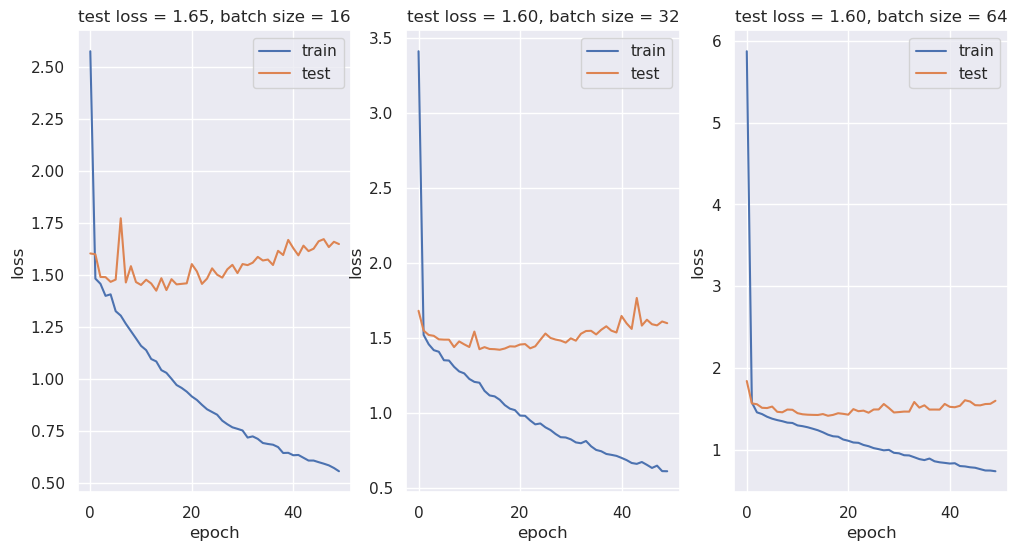

Best batch size: 32 (val_loss=1.5998)


In [13]:
# Pre-convert training and test arrays once (proposal 1: avoid redundant conversion in loop)
# 4.) trying network parameters from cell above to search for best batch size with smallest test loss
# showing off visually

X_train = np.array(list(x_train)).astype(float)
X_test = np.array(list(x_test)).astype(float)

# Plot
fig = plt.figure(figsize=(12, 6))
sns.set_theme(color_codes=True)
best_batch = batch_sizes[0]
best_val_loss = float("inf")
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        X_train,
        y_train.values,
        batch_size=batch,
        validation_data=(X_test, y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    first_loss = history.history["loss"][0]
    print(f"Batch {batch}: first loss = {first_loss:.4f}")  # NaN here means bad input data
    final_val_loss = history.history["val_loss"][nb_epoch - 1]
    # saving best batch size based on least test loss
    if final_val_loss < best_val_loss:
        best_val_loss = final_val_loss
        best_batch = batch
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()
print(f"Best batch size: {best_batch} (val_loss={best_val_loss:.4f})")

Now, we train the model with an automatically chosen batch size (because as seen from the figure above, it has the lowest test loss) and we save the weights that give the best perfomance in the file best_weights.h5.

In [14]:
# 4.) Save and fit the trained model

filepath = HERE / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    X_train,
    y_train.values,
    epochs=nb_epoch,
    batch_size=best_batch,
    callbacks=callbacks_list,
    verbose=0,
)

In [15]:
# 4.) Evalute the models performance based on the test data
# save in csv for performance comparison

print(f"Evaluate the model on the test data")
scores = model.evaluate(X_test, y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}") #mean squared error
print(f" mae: {scores[2]:.2f}") #mean absolute error

y_pred_eval = model.predict(X_test, verbose=0)
r2 = metrics.r2_score(y_test.values, y_pred_eval)
print(f" R²: {r2:.4f}")

# Append metrics to CSV (one row per run)
metrics_path = HERE / "model_metrics.csv"
new_row = pd.DataFrame([{
    "training_data": DATA.name,
    "timestamp": datetime.datetime.now().isoformat(),
    "train_samples": X_train.shape[0],
    "train_features": X_train.shape[1],
    "nb_epoch": nb_epoch,
    "best_batch": best_batch,
    "from_batch_sizes": batch_sizes,
    "layer1_size": layer1_size,
    "layer2_size": layer2_size,
    "loss": scores[0],
    "mse": scores[1],
    "mae": scores[2],
    "r2": r2,
}])
new_row = new_row.set_index("training_data")
if metrics_path.exists():
    new_row.to_csv(metrics_path, mode="a", header=False)
else:
    new_row.to_csv(metrics_path)
print(f"Metrics appended to {metrics_path}")


Evaluate the model on the test data
 loss: 1.86
 mse (same as loss): 1.86
 mae: 1.07
 R²: -0.0095
Metrics appended to /storage/homefs/hg21b070/datasc_kinase/model_metrics.csv


### Predictions on test set

In [16]:
# 4.) Apply model on test data to compare predicted pIC50 values with measured pIC50 values

# Predict pIC50 values on x_test data
y_pred = model.predict(X_test)

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
7.84
6.05
4.77
6.93
5.20


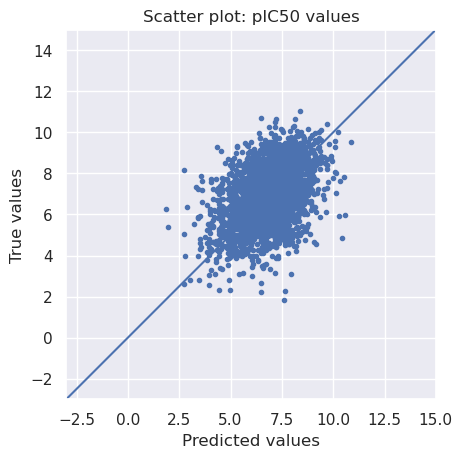

In [17]:
# 4.) Scatter plot visually showing predicted vs true pIC50 values for the test set

limits = -3, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

### 4.) Go on external data
thought it might be good to have inhibitors of same kinase but do not know of what kinase the training data is. fit should be better on inhibitors of same kinases but kinases are very conservative and this react similarly to kinase-inhibitors. though smiles of chemicals completely different from kinase-inhibitors should have predicted high half maximal inhibitory concentration CI50 if the model is good. So low pCI50 close to 1.

In [18]:
# 4.) Load external/unlabeled data set (i.e: mouse pKi TSV, SMILES column only)
# to adjust data format check file before

external_data = pd.read_csv(HERE / "mouse_PKI_inactive.tsv", sep="\t", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data = external_data[["nonstereo_aromatic_smiles"]].rename(columns={"nonstereo_aromatic_smiles": "smiles"})
# If the source column has a different name, update the key below:
# external_data = external_data[["Smiles"]].rename(columns={"Smiles": "smiles"})
print("Shape:", external_data.shape)
external_data.head()
# NBVAL_CHECK_OUTPUT

Shape: (522, 1)


,smiles
0,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nncs2)cc1
1,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C)s2)cc1
2,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C(C)(C)C)...
3,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(CO)s2)cc1
4,CCCCCCCCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1


In [19]:
# 4.) Convert SMILES strings to MACCS fingerprints for the external/unlabeled data set
# same data processing as for the training data, but no split needed

# Convert SMILES strings to MACCS fingerprints
external_data["fingerprints_df"] = external_data["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (522, 2)


,smiles,fingerprints_df
0,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nncs2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C)s2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C(C)(C)C)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [20]:
# Rebuild model architecture and load the saved best weights for
#  model application on external/unlabeled data
# pay attention to ending of file

model = neural_network_model(layer1_size, layer2_size)
model.build(input_shape=(None, X_train.shape[1]))
model.load_weights(str(HERE / "best_weights.weights.h5"))

In [21]:
# 4.) Prediction on external/unlabeled data using the trained model
# looking at head and saving csv for later checking

predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(3)

# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(HERE / "predicted_pIC50_df.csv")

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [22]:
# 4.) Selecting top 3 drugs of the external/unlabeled data
#  based on the predicted pIC50 values

predicted_pIC50_df = pd.read_csv(HERE / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,smiles,fingerprints_df,predicted_pIC50
319,Cc1cccc(-c2nn3c(c2-c2ccnc(Cl)c2)C(C)C(C)(C)C3)n1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,9.958934
449,CC(C)c1cnc(-c2cc(Cl)ccc2F)cc1Nc1ccncc1C(=O)NC(...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,9.623711
151,Cc1cccc(-c2nn3c(c2-c2ccc(O)cc2)C(C)C(C)(C)C3)n1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,9.519357


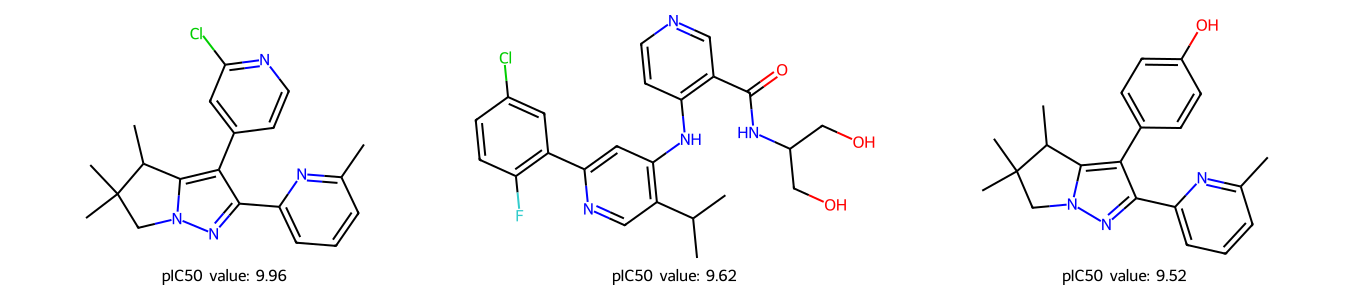

In [23]:
# 4.) Drawing the drug molecules using RDKit based on the SMILES of top 3 drugs

highest_pIC50 = predicted_pIC50_df["smiles"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)